# Neuronale Netze – Grundlagen

Willkommen zum ersten Notebook der Exploration-Phase. Wir bauen hier Schritt für Schritt ein neuronales Netz **von Grund auf** und schauen uns an, was in jedem Schritt mathematisch passiert – kein Black-Box-Training.

**Ziel:** Ein kleines Netz soll ein unbekanntes physikalisches Signal approximieren – einen einzelnen "Peak" (Gauß-Kurve), wie er z. B. bei einer Absorptions- oder Emissionslinie auftaucht. Solchen Rekonstruktionsproblemen begegnen wir später im Projekt (Spektroskopie) wieder – hier geht es aber erstmal nur um die Grundlagen neuronaler Netze.

**Ablauf:**
1. Tensoren
2. Die Daten – ein synthetisches Messsignal
3. Das einfachste Modell: eine lineare Abbildung
4. Fehler messen – die Loss-Funktion
5. Gradienten & Backpropagation
6. Ein Trainingsschritt von Hand (Gradient Descent)
7. Vom linearen Modell zum MLP
8. Optimierer & Trainings-Loop
9. Interaktiv experimentieren
10. Ausblick: Overfitting
11. Zusammenfassung & weiterführende Ressourcen

> Stil-Hinweis: Wir folgen hier demselben Prinzip wie die empfehlenswerten [PINN-Lecture-Notes von J. Sappl](https://jsappl.github.io/pinns/) – erst Intuition, dann ein kleines Beispiel, dann Code, dann Ergebnis anschauen, dann selbst etwas verändern.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
print("PyTorch-Version:", torch.__version__)

PyTorch-Version: 2.13.0


## 1. Tensoren

Ein `Tensor` ist die Grundeinheit von PyTorch – im Kern ein mehrdimensionales Array wie ein NumPy-Array, aber mit zwei Zusatzfähigkeiten:

- er kann auf der GPU rechnen,
- er kann sich merken, wie er berechnet wurde, um automatisch Ableitungen zu bilden (`requires_grad=True`, dazu gleich mehr).

Das reicht für den Einstieg – schauen wir uns ein paar Tensoren an.

In [2]:
x = torch.tensor([[[1.0, 2.0, 3.0, 4.0],[1.0, 2.0, 3.0, 4.0],[5.0, 6.0, 7.0, 8.0]],[[1.0, 2.0, 3.0, 4.0],[1.0, 2.0, 3.0, 4.0],[5.0, 6.0, 7.0, 8.0]]])
print(x, x.shape, x.dtype, x.requires_grad)  

y = torch.linspace(-3, 3, 5)
print(y, y.shape, y.dtype, y.requires_grad)

a = torch.tensor(2.0, requires_grad=True)
print(a, a.shape, a.dtype, a.requires_grad)

tensor([[[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [5., 6., 7., 8.]],

        [[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [5., 6., 7., 8.]]]) torch.Size([2, 3, 4]) torch.float32 False
tensor([-3.0000, -1.5000,  0.0000,  1.5000,  3.0000]) torch.Size([5]) torch.float32 False
tensor(2., requires_grad=True) torch.Size([]) torch.float32 True


`requires_grad=True` sagt PyTorch: "merk dir, wie dieser Wert in spätere Rechnungen eingeht, damit du später $\partial(\text{Ergebnis})/\partial a$ bilden kannst." Das ist die Grundlage von Backpropagation (Abschnitt 5).

## 2. Die Daten – ein synthetisches Messsignal

Statt echter Messdaten erzeugen wir uns ein bekanntes "wahres" Signal $f(x)$ – einen Gauß-Peak – und simulieren verrauschte Messpunkte davon. So kennen wir die Ground Truth und können später beurteilen, wie gut das Modell wirklich ist.

$$f(x) = \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right), \quad \mu = 0.5,\ \sigma = 0.4$$

Wir teilen die Punkte außerdem in **Trainings-** und **Validierungsdaten** auf: Trainiert wird nur auf den Trainingsdaten, die Validierungsdaten dienen später als ehrlicher Test, ob das Modell wirklich das Signal gelernt hat und nicht nur die Trainingspunkte auswendig.

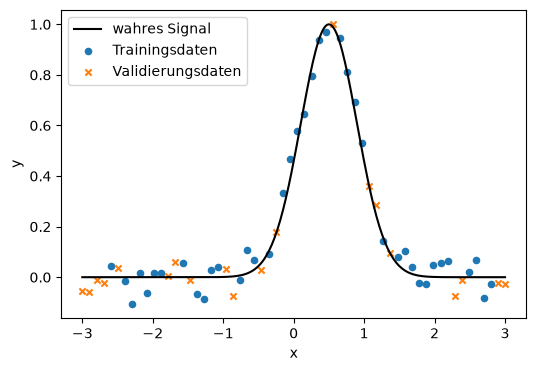

In [3]:
def true_signal(x):
    return torch.exp(-((x - 0.5) ** 2) / (2 * 0.4 ** 2))

n_samples = 60
x_data = torch.linspace(-3, 3, n_samples).unsqueeze(1)
noise = 0.05 * torch.randn(n_samples, 1)
y_data = true_signal(x_data) + noise

n_train = 40
perm = torch.randperm(n_samples)
train_idx, val_idx = perm[:n_train], perm[n_train:]

x_train, y_train = x_data[train_idx], y_data[train_idx]
x_val, y_val = x_data[val_idx], y_data[val_idx]

x_plot = torch.linspace(-3, 3, 300).unsqueeze(1)

plt.figure(figsize=(6, 4))
plt.plot(x_plot, true_signal(x_plot), label="wahres Signal", color="black")
plt.scatter(x_train, y_train, label="Trainingsdaten", s=20)
plt.scatter(x_val, y_val, label="Validierungsdaten", s=20, marker="x")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 3. Das einfachste Modell: eine lineare Abbildung

Bevor wir ein "neuronales Netz" bauen, starten wir mit dem einfachsten denkbaren Modell – einer Geraden:

$$\hat y = w \cdot x + b$$

- $w$ (Gewicht/*weight*) ist die Steigung,
- $b$ (Bias) ist der Achsenabschnitt.

Beide sind zunächst zufällig initialisiert – das Modell hat noch nichts gelernt.

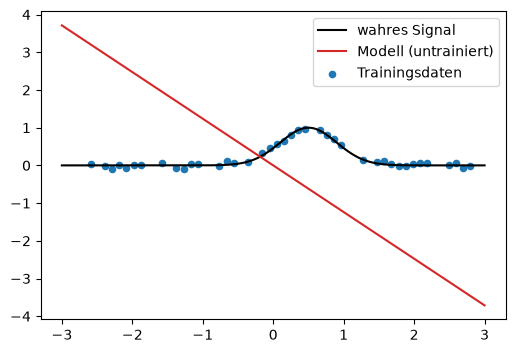

w = -1.238, b = 0.000


In [4]:
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def linear_model(x):
    return w * x + b

y_pred = linear_model(x_plot)

plt.figure(figsize=(6, 4))
plt.plot(x_plot, true_signal(x_plot), label="wahres Signal", color="black")
plt.plot(x_plot, y_pred.detach(), label="Modell (untrainiert)", color="tab:red")
plt.scatter(x_train, y_train, label="Trainingsdaten", s=20)
plt.legend()
plt.show()

print(f"w = {w.item():.3f}, b = {b.item():.3f}")

## 4. Fehler messen: die Loss-Funktion

Um "gut" oder "schlecht" objektiv zu machen, brauchen wir ein Fehlermaß. Der Klassiker für Regression ist der **mittlere quadratische Fehler** (Mean Squared Error, MSE):

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^N \left(\hat y_i - y_i\right)^2$$

Große Abweichungen werden quadratisch bestraft, kleine kaum. Je kleiner $\mathcal{L}$, desto besser passt das Modell zu den Daten.

In [5]:
def mse_loss(y_hat, y):
    return torch.mean((y_hat - y) ** 2)

loss = mse_loss(linear_model(x_train), y_train)
print(f"Loss (untrainiert): {loss.item():.4f}")

Loss (untrainiert): 4.4010


## 5. Gradienten & Backpropagation

Wir wollen $w$ und $b$ so verändern, dass $\mathcal{L}$ kleiner wird. Dafür brauchen wir die Ableitungen $\partial \mathcal{L}/\partial w$ und $\partial \mathcal{L}/\partial b$ – sie zeigen, in welche Richtung sich $\mathcal{L}$ am stärksten *erhöht*, wenn wir $w$ bzw. $b$ ein kleines Stück ändern (dieselbe Idee wie ein Gradient in der Physik, z. B. $-\nabla U$ für die Kraft aus einem Potential).

PyTorch berechnet diese Ableitungen automatisch per **Backpropagation**: `loss.backward()` läuft den Rechenweg, der zu `loss` geführt hat, rückwärts durch und wendet dabei wiederholt die Kettenregel an. Das Ergebnis landet in `w.grad` und `b.grad`.

In [6]:
loss = mse_loss(linear_model(x_train), y_train)
loss.backward()

print(f"dLoss/dw = {w.grad.item():.4f}")
print(f"dLoss/db = {b.grad.item():.4f}")

dLoss/dw = -6.6609
dLoss/db = -0.8243


## 6. Ein Trainingsschritt von Hand (Gradient Descent)

Die Idee des **Gradientenabstiegs**: Wir gehen ein kleines Stück *entgegen* dem Gradienten, weil der Gradient in die Richtung des steilsten *Anstiegs* zeigt und wir den Loss ja *senken* wollen:

$$w \leftarrow w - \eta \, \frac{\partial \mathcal{L}}{\partial w}, \qquad b \leftarrow b - \eta \, \frac{\partial \mathcal{L}}{\partial b}$$

$\eta$ (die *learning rate*) bestimmt die Schrittweite. Das machen wir jetzt einmal komplett von Hand, ohne `torch.optim` – so ist klar, was ein Optimierer später eigentlich tut. Ein Detail: Gradienten werden von PyTorch bei jedem `backward()` *aufaddiert*, deshalb müssen wir sie vor jedem Schritt manuell auf null setzen.

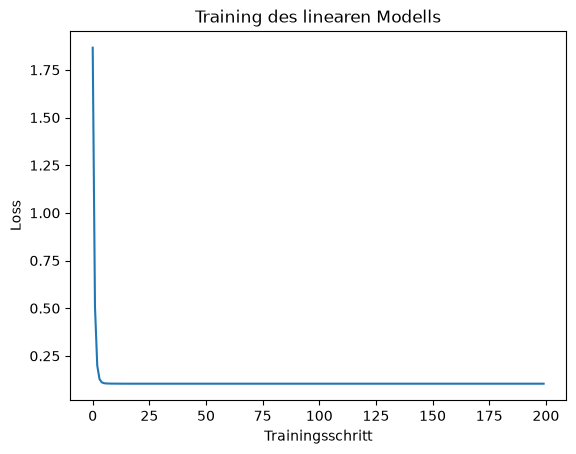

finaler Loss: 0.1041, w = 0.028, b = 0.203


In [7]:
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 0.1

loss_history = []
for _ in range(200):
    y_hat = linear_model(x_train)
    loss = mse_loss(y_hat, y_train)

    if w.grad is not None:
        w.grad.zero_()
        b.grad.zero_()
    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    loss_history.append(loss.item())

plt.plot(loss_history)
plt.xlabel("Trainingsschritt")
plt.ylabel("Loss")
plt.title("Training des linearen Modells")
plt.show()

print(f"finaler Loss: {loss_history[-1]:.4f}, w = {w.item():.3f}, b = {b.item():.3f}")

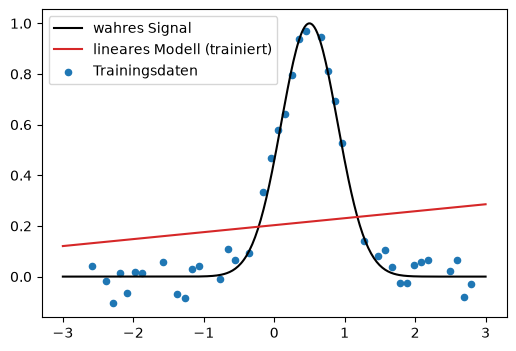

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(x_plot, true_signal(x_plot), label="wahres Signal", color="black")
plt.plot(x_plot, linear_model(x_plot).detach(), label="lineares Modell (trainiert)", color="tab:red")
plt.scatter(x_train, y_train, label="Trainingsdaten", s=20)
plt.legend()
plt.show()

**Beobachtung:** Der Loss sinkt und $w,b$ finden die bestmögliche Gerade – aber egal wie gut $w$ und $b$ trainiert sind, eine Gerade kann einen Peak nicht abbilden. Das Modell ist strukturell zu einfach (*underfitting*). Wir brauchen Nichtlinearität.

## 7. Vom linearen Modell zum MLP

Eine Verkettung mehrerer linearer Abbildungen ist wieder nur eine lineare Abbildung ($W_2(W_1 x + b_1) + b_2$ lässt sich zu einer einzigen linearen Funktion zusammenfassen). Um wirklich mehr Ausdruckskraft zu bekommen, fügen wir zwischen den linearen Schichten eine **Aktivierungsfunktion** ein – eine einfache nichtlineare Funktion, hier $\tanh$.

Ein **Multi-Layer Perceptron (MLP)** ist genau das: abwechselnd lineare Schichten und Aktivierungsfunktionen. Statt `w * x + b` von Hand zu schreiben, nutzen wir jetzt `torch.nn`, das diese Bausteine fertig mitbringt.

In [ ]:
class MLP(nn.Module):                      # erbt von nn.Module -> bekommt parameters(), __call__, train()/eval(), .to() ... geschenkt
    def __init__(self, hidden_dim=16):
        super().__init__()                 # ruft nn.Module.__init__ auf: legt die interne Buchhaltung fuer Parameter/Submodule an -> MUSS als erste Zeile stehen
        self.net = nn.Sequential(          # Container-Modul: schiebt die Eingabe der Reihe nach durch alle Bausteine
            nn.Linear(1, hidden_dim),      # lineare Schicht  h = x @ W1.T + b1 : 1 Feature rein, hidden_dim raus. W1, b1 sind Tensoren mit requires_grad=True
            nn.Tanh(),                     # elementweise Nichtlinearitaet, KEINE Parameter. Ohne sie waere Linear->Linear zusammen wieder nur eine Gerade
            nn.Linear(hidden_dim, 1),      # lineare Schicht  y = h @ W2.T + b2 : hidden_dim rein, 1 Vorhersage raus
        )
        # Zuweisung an self.net wird von nn.Module automatisch als Submodul registriert -> W1,b1,W2,b2 tauchen dann in model.parameters() auf

    def forward(self, x):                  # definiert den Forward Pass. NICHT direkt aufrufen -> stattdessen model(x), siehe unten
        return self.net(x)                 # x: shape (N, 1)  ->  Rueckgabe: shape (N, 1)

model = MLP(hidden_dim=16)                 # erzeugt das Objekt und ruft dabei automatisch __init__(hidden_dim=16) auf
print(model)                              # nutzt das von nn.Module geerbte __repr__ -> eingerueckte Baumdarstellung der Submodule

n_params = sum(p.numel() for p in model.parameters())  # parameters(): Iterator ueber alle Gewichts-Tensoren; p.numel(): Anzahl Elemente darin
print(f"Anzahl trainierbarer Parameter: {n_params}")   # 16*1 (W1) + 16 (b1) + 1*16 (W2) + 1 (b2) = 49


## 8. Optimierer & Trainings-Loop

`w -= lr * w.grad` von Hand war Gradientenabstieg in seiner einfachsten Form. `torch.optim` bietet fertige, verfeinerte Varianten davon – wir nutzen `Adam`, der die Schrittweite pro Parameter adaptiv anpasst und in der Praxis meist schneller konvergiert. Das Grundprinzip (Gradient berechnen, Parameter entgegen dem Gradienten verschieben) bleibt exakt dasselbe.

Wir schreiben uns eine kleine, wiederverwendbare `train`-Funktion, die zusätzlich den Loss auf den Validierungsdaten mitprotokolliert (dort *kein* `backward()` bzw. `optimizer.step()` – nur beobachten, nicht trainieren).

In [ ]:
def train(model, x_train, y_train, x_val, y_val, lr=0.01, epochs=500):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # der Optimierer bekommt eine Referenz auf ALLE Parameter-Tensoren + die Lernrate. Ersetzt das "w -= lr*w.grad" von Hand
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        optimizer.zero_grad()                     # p.grad fuer jeden Parameter auf 0 setzen. Noetig, weil backward() Gradienten AUFADDIERT (vgl. Abschnitt 6)
        loss = mse_loss(model(x_train), y_train)  # model(x_train): Forward Pass -> Vorhersagen shape (40,1). Dabei baut PyTorch den Rechen-Graphen mit auf. Dann MSE gegen echte y_train
        loss.backward()                           # Backpropagation: laeuft den Graphen rueckwaerts, schreibt dLoss/dp in jedes p.grad
        optimizer.step()                          # ein Update-Schritt: fuer jeden Parameter  p <- p - lr * (von Adam angepasstes) p.grad

        train_losses.append(loss.item())          # .item(): 0-dim-Tensor -> reine Python-float. Loest die Referenz auf den Graphen, sonst waechst der Speicher
        with torch.no_grad():                     # in diesem Block KEINEN Graphen aufbauen: wir wollen hier nur messen, nie backward() darauf aufrufen -> spart Speicher/Zeit
            val_losses.append(mse_loss(model(x_val), y_val).item())  # gleiche Kennzahl auf den ungesehenen Val-Daten. Kein backward, kein step -> reines Beobachten

    return train_losses, val_losses

model = MLP(hidden_dim=16)                        # frisches Modell mit zufaellig initialisierten Gewichten
train_losses, val_losses = train(model, x_train, y_train, x_val, y_val, lr=0.01, epochs=500)

plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validierung")
plt.yscale("log")                                # Loss faellt ueber Groessenordnungen -> log-Achse macht spaete Epochen ueberhaupt erst lesbar
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()
plt.show()

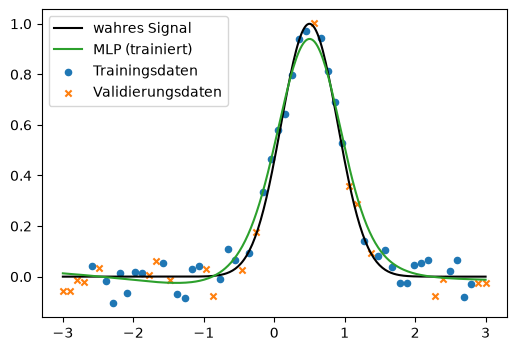

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(x_plot, true_signal(x_plot), label="wahres Signal", color="black")
with torch.no_grad():
    plt.plot(x_plot, model(x_plot), label="MLP (trainiert)", color="tab:green")
plt.scatter(x_train, y_train, label="Trainingsdaten", s=20)
plt.scatter(x_val, y_val, label="Validierungsdaten", s=20, marker="x")
plt.legend()
plt.show()

Jetzt kann das Modell den Peak abbilden – der Unterschied zum linearen Modell ist rein die hinzugefügte Nichtlinearität.

## 9. Interaktiv experimentieren

Jetzt bist du dran. Der folgende Slider trainiert bei jeder Änderung ein frisches MLP neu und zeigt Loss-Kurve und Fit. Probiere gezielt aus:

- `hidden_dim = 1`: kaum mehr Kapazität als das lineare Modell — was passiert mit dem Fit?
- `lr` sehr groß (> 0.1): Loss-Kurve wird instabil oder explodiert.
- `epochs` sehr klein: Underfitting — das Training ist noch nicht fertig.
- `noise_level` hoch zusammen mit großem `hidden_dim` und vielen `epochs`: worauf achten, um Overfitting zu erkennen? (mehr dazu in Abschnitt 10)

In [12]:
from ipywidgets import interact, IntSlider, FloatLogSlider

def experiment(hidden_dim=16, lr=0.01, epochs=300, noise_level=0.05):
    torch.manual_seed(0)
    noisy_y_train = true_signal(x_train) + noise_level * torch.randn_like(x_train)

    model = MLP(hidden_dim=hidden_dim)
    train_losses, _ = train(model, x_train, noisy_y_train, x_val, y_val, lr=lr, epochs=epochs)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(train_losses)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Epoche")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"finaler Loss: {train_losses[-1]:.4f}")

    axes[1].plot(x_plot, true_signal(x_plot), label="wahres Signal", color="black")
    with torch.no_grad():
        axes[1].plot(x_plot, model(x_plot), label="MLP", color="tab:green")
    axes[1].scatter(x_train, noisy_y_train, label="Trainingsdaten", s=20)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

interact(
    experiment,
    hidden_dim=IntSlider(min=1, max=64, step=1, value=16),
    lr=FloatLogSlider(min=-4, max=-1, step=0.1, value=0.01, base=10),
    epochs=IntSlider(min=10, max=1000, step=10, value=300),
    noise_level=FloatLogSlider(min=-3, max=0, step=0.1, value=0.05, base=10),
);

interactive(children=(IntSlider(value=16, description='hidden_dim', max=64, min=1), FloatLogSlider(value=0.01,…

## 10. Ausblick: Overfitting

Ein Modell mit sehr viel Kapazität (großes `hidden_dim`) kann bei genug Trainingsschritten anfangen, das Rauschen in den Trainingsdaten mitzulernen statt nur das eigentliche Signal. Der Trainings-Loss sinkt dann immer weiter, während der Validierungs-Loss stagniert oder wieder ansteigt — genau der train/val-Split von Abschnitt 2 macht dieses Auseinanderlaufen erst sichtbar.

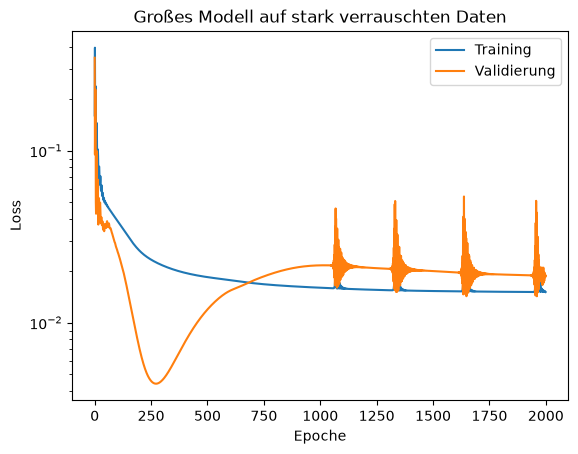

In [13]:
torch.manual_seed(1)
noisy_y_train = true_signal(x_train) + 0.15 * torch.randn_like(x_train)

model_big = MLP(hidden_dim=128)
train_losses, val_losses = train(model_big, x_train, noisy_y_train, x_val, y_val, lr=0.01, epochs=2000)

plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validierung")
plt.yscale("log")
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.title("Großes Modell auf stark verrauschten Daten")
plt.legend()
plt.show()

**Beobachtung:** Trainings- und Validierungs-Loss laufen auseinander — das Modell wird auf den Trainingsdaten immer besser, ohne dass es dem wahren Signal noch näherkommt. Das ist Overfitting. Regularisierung und Modellwahl dagegen sind Thema eines späteren Notebooks, sobald sie im Kontext von `05_inverse_problems` gebraucht werden.

## 11. Zusammenfassung

- **Tensor** + `requires_grad` als Grundlage von Autograd
- **Forward Pass**: Modell wendet Parameter auf Eingabe an
- **MSE-Loss** als Fehlermaß
- **Backpropagation** (`loss.backward()`) berechnet Gradienten automatisch per Kettenregel
- **Gradientenabstieg** von Hand vs. `torch.optim` (gleiches Prinzip, mehr Komfort)
- **Lineares Modell vs. MLP**: Nichtlinearität (Aktivierungsfunktion) ist nötig, um mehr als Geraden abzubilden
- **Train/Validation-Split** macht Overfitting sichtbar

### Weiterführende Ressourcen

- [PINN Lecture Notes (J. Sappl)](https://jsappl.github.io/pinns/) — math-first, mit Julia-Code; guter Anschluss, sobald DGLs (`04_odes`) und PINNs (`06_pinns`) dran sind. Der Aufbau dieses Notebooks (Intuition → kleines Beispiel → Code → Ergebnis anschauen → selbst verändern) orientiert sich an diesem Stil.
- [Andrej Karpathy – micrograd](https://github.com/karpathy/micrograd): eine Autograd-Engine in ca. 100 Zeilen Python komplett von Grund auf selbst gebaut — sehr zu empfehlen, um Backpropagation wirklich zu verstehen statt sie nur zu benutzen.
- [PyTorch – Learn the Basics](https://docs.pytorch.org/tutorials/beginner/basics/intro.html): offizielles Tutorial, gute Referenz für Tensor-/API-Details.
- [dair-ai/pytorch_notebooks](https://github.com/dair-ai/pytorch_notebooks): kompakte Notebook-Sammlung, u. a. "Neural Network from Scratch".

Keines davon war so exakt auf diesen Einstieg (Physik-Framing, Schritt-für-Schritt von Hand vor `torch.optim`, interaktive Slider) zugeschnitten, dass sich ein 1:1-Kopieren gelohnt hätte — daher hier als Links statt als vendorte Kopien im Ordner.

**Nächstes Notebook:** `02_pytorch` — tiefer in die PyTorch-API (Datasets/DataLoader, GPU, `nn.Module`-Patterns), bevor es in `03_autodiff` im Detail um Automatic Differentiation geht.